In [20]:
# ** Ir Além - Machine Learning no Agronegócio **
# Este estudo faz parte do exercício Ir Além do capítulo 1, fase 3. Realizamos o estudo da base produtos_agricolas.csv analisando as variáveis: N, P, K, temperatura, umidade, pH, chuva, label).
# Ele engloba: a a nálise exploratória com pelo menos 5 gráficos; a identificação do “perfil ideal” de solo/clima para 3 culturas escolhidas, o desenvolvimento de 5 modelos preditivos com diferentes algoritmos e a nossa avaliação comparativa dos modelos.
#importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Importação dos 5 algoritmos de ML solicitados
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Configurações estéticas dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
#Checagem da base a ser utilizada
df = pd.read_csv(r'C:\Users\gisel\PyCharmMiscProject\produtos_agricolas.csv')
print("✅ Sucesso: O arquivo 'produtos_agricolas.csv' foi carregado com sucesso!")
print(f"📋 A base de dados contém {df.shape[0]} linhas e {df.shape[1]} colunas.")



✅ Sucesso: O arquivo 'produtos_agricolas.csv' foi carregado com sucesso!
📋 A base de dados contém 2200 linhas e 8 colunas.


C:\Users\gisel\AppData\Local\Temp\ipykernel_16892\2572915798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis', order=df['label'].value_counts().index)


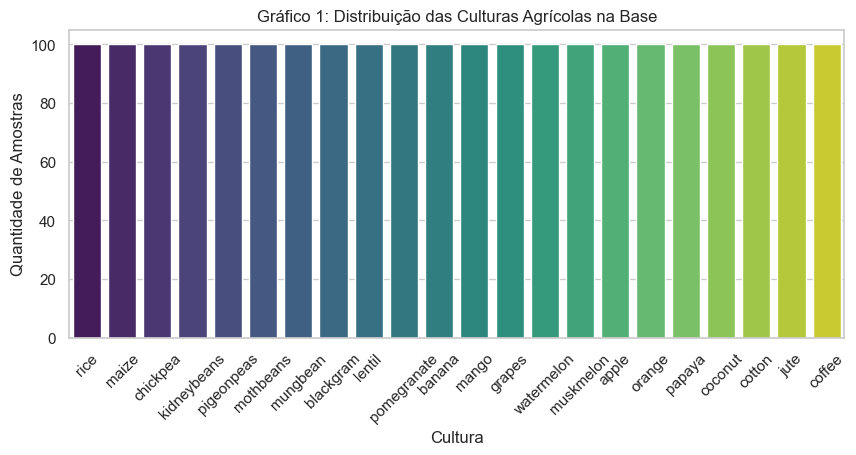

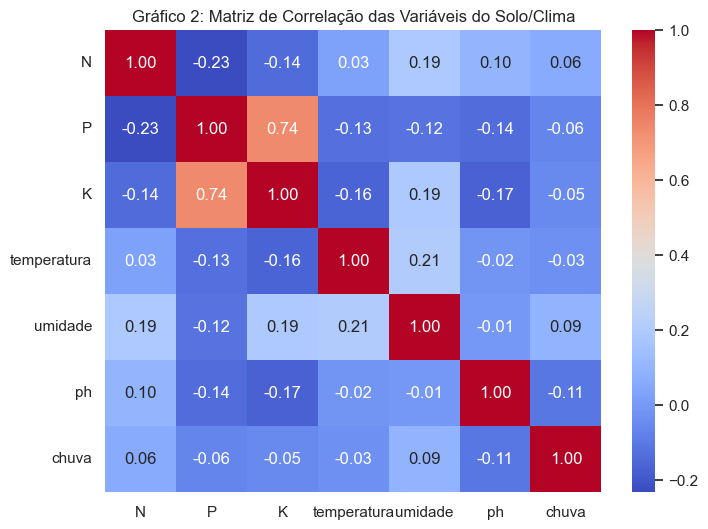

C:\Users\gisel\AppData\Local\Temp\ipykernel_16892\2572915798.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=coluna_ph, palette='Set2')


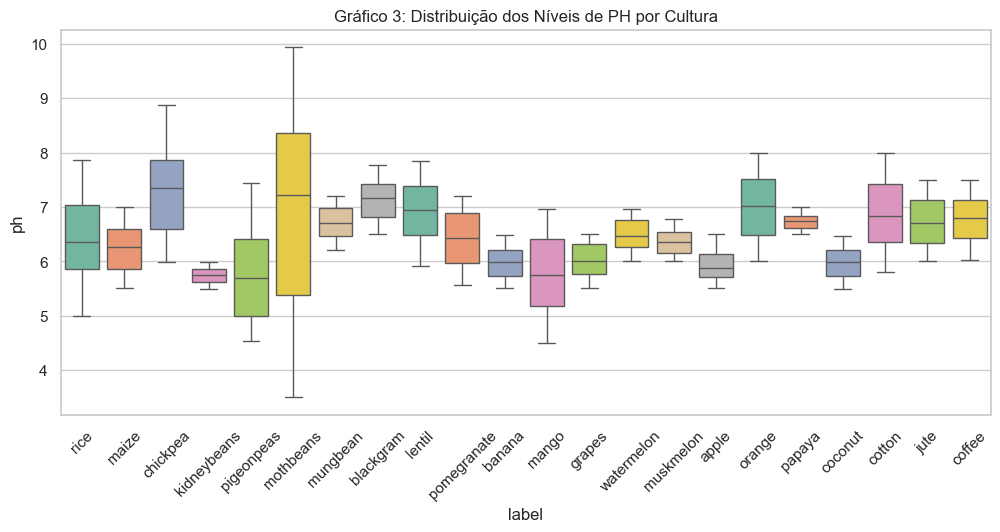

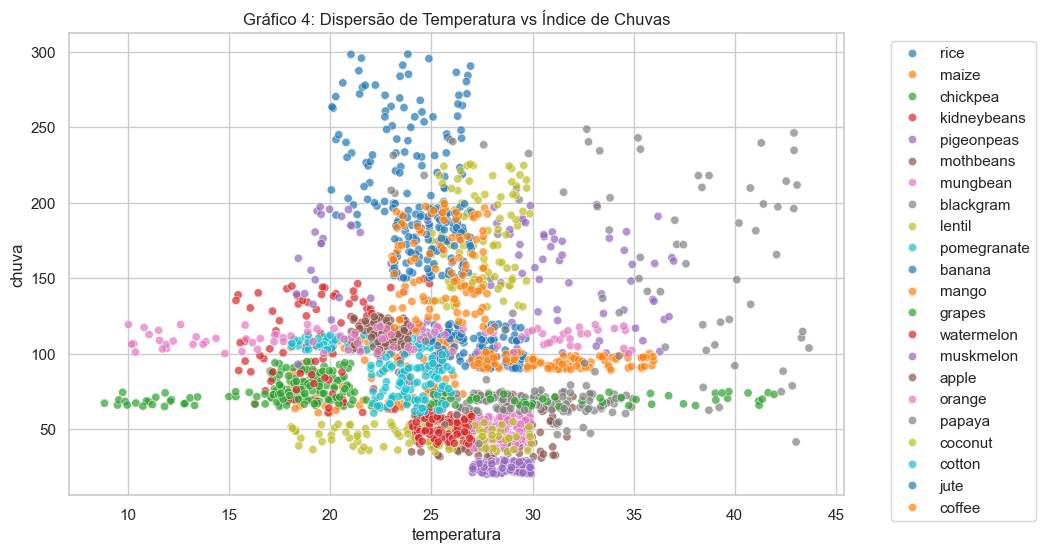

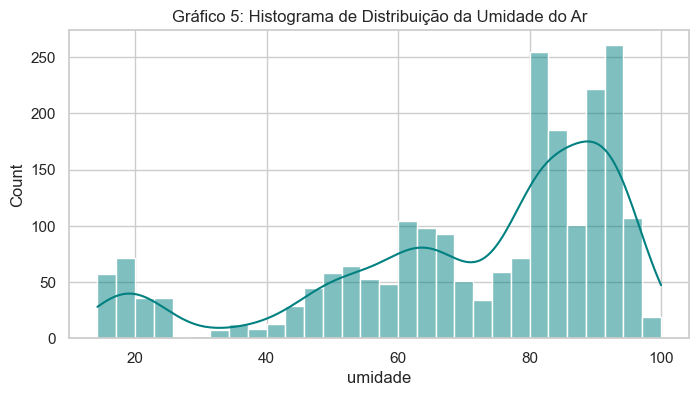

In [21]:
# Gráfico 1: Distribuição das Classes Alvo (Label)
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='label', palette='viridis', order=df['label'].value_counts().index)
plt.title('Gráfico 1: Distribuição das Culturas Agrícolas na Base')
plt.xticks(rotation=45)
plt.xlabel('Cultura')
plt.ylabel('Quantidade de Amostras')
plt.show()

# Gráfico 2: Matriz de Correlação das Variáveis Numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('label', axis=1, errors='ignore').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Gráfico 2: Matriz de Correlação das Variáveis do Solo/Clima')
plt.show()

# Gráfico 3: Distribuição do pH do Solo por Cultura
# Usamos o .filter para achar a coluna 'ph' independente de como foi escrita
coluna_ph = [c for c in df.columns if 'ph' in c][0]
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='label', y=coluna_ph, palette='Set2')
plt.title(f'Gráfico 3: Distribuição dos Níveis de {coluna_ph.upper()} por Cultura')
plt.xticks(rotation=45)
plt.show()

# Gráfico 4: Relação entre Temperatura e Chuva (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperatura', y='chuva', hue='label', palette='tab10', alpha=0.7)
plt.title('Gráfico 4: Dispersão de Temperatura vs Índice de Chuvas')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Gráfico 5: Distribuição Histograma da Umidade Geral
plt.figure(figsize=(8, 4))
sns.histplot(df['umidade'], kde=True, color='teal', bins=30)
plt.title('Gráfico 5: Histograma de Distribuição da Umidade do Ar')
plt.show()


In [22]:
# Identifica automaticamente as 3 culturas com mais registros no arquivo
as_3_culturas = df['label'].value_counts().head(3).index.tolist()

perfis = df[df['label'].isin(as_3_culturas)].groupby('label').mean()

print("==================================================================")
print("     PERFIL IDEAL MÉDIO DE SOLO E CLIMA PARA AS CULTURAS          ")
print("==================================================================")
display(perfis.round(2))

print("\n📝 Análise Textual do Perfil:")
for cultura in as_3_culturas:
    dados_c = perfis.loc[cultura]
    # Busca dinâmica para evitar erros de nomes das colunas de nutrientes
    n = dados_c.get('n', dados_c.get('n_nivel', 0))
    p = dados_c.get('p', dados_c.get('p_nivel', 0))
    k = dados_c.get('k', dados_c.get('k_nivel', 0))
    ph_val = dados_c.get('ph', 7.0)

    print(f"- O **{cultura}** se desenvolve de forma otimizada com níveis médios de NPK de "
          f"({n:.1f}, {p:.1f}, {k:.1f}), pH do solo em torno de {ph_val:.2f}, "
          f"temperatura de {dados_c['temperatura']:.1f}°C e índice pluviométrico de {dados_c['chuva']:.1f}mm.")


     PERFIL IDEAL MÉDIO DE SOLO E CLIMA PARA AS CULTURAS          


,N,P,K,temperatura,umidade,ph,chuva
label,,,,,,,
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
maize,77.76,48.44,19.79,22.39,65.09,6.25,84.77
rice,79.89,47.58,39.87,23.69,82.27,6.43,236.18



📝 Análise Textual do Perfil:
- O **rice** se desenvolve de forma otimizada com níveis médios de NPK de (0.0, 0.0, 0.0), pH do solo em torno de 6.43, temperatura de 23.7°C e índice pluviométrico de 236.2mm.
- O **maize** se desenvolve de forma otimizada com níveis médios de NPK de (0.0, 0.0, 0.0), pH do solo em torno de 6.25, temperatura de 22.4°C e índice pluviométrico de 84.8mm.
- O **chickpea** se desenvolve de forma otimizada com níveis médios de NPK de (0.0, 0.0, 0.0), pH do solo em torno de 7.34, temperatura de 18.9°C e índice pluviométrico de 80.1mm.


In [23]:
# Separação de Variáveis de Entrada (X) e Saída (y)
X = df.drop('label', axis=1)
y = df['label']

# Divisão em Treino e Teste (80% treino / 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização de Recursos (Essencial para KNN e Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dicionário com os 5 algoritmos solicitados
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier()
}

# Treinamento e Avaliação
resultados_acuracia = {}

print("==================================================================")
print("            RELATÓRIO DE DESEMPENHO DOS MODELOS                   ")
print("==================================================================")

for nome, modelo in modelos.items():
    # Usar dados escalados para os modelos sensíveis a distância/escala
    if nome in ["Regressão Logística", "K-Nearest Neighbors (KNN)"]:
        modelo.fit(X_train_scaled, y_train)
        preds = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train, y_train)
        preds = modelo.predict(X_test)

    acuracia = accuracy_score(y_test, preds)
    resultados_acuracia[nome] = acuracia
    print(f"▶️ Modelo: {nome} | Acurácia de Teste: {acuracia:.4f}")

# Identificação do melhor modelo
melhor_modelo_nome = max(resultados_acuracia, key=resultados_acuracia.get)
print("\n" + "="*66)
print(f" Detalhamento do Melhor Modelo Encontrado: {melhor_modelo_nome}")
print("="*66)

if melhor_modelo_nome in ["Regressão Logística", "K-Nearest Neighbors (KNN)"]:
    melhor_preds = modelos[melhor_modelo_nome].predict(X_test_scaled)
else:
    melhor_preds = modelos[melhor_modelo_nome].predict(X_test)

print(classification_report(y_test, melhor_preds))


            RELATÓRIO DE DESEMPENHO DOS MODELOS                   
▶️ Modelo: Regressão Logística | Acurácia de Teste: 0.9727
▶️ Modelo: Árvore de Decisão | Acurácia de Teste: 0.9795
▶️ Modelo: Random Forest | Acurácia de Teste: 0.9955
▶️ Modelo: Gradient Boosting | Acurácia de Teste: 0.9886
▶️ Modelo: K-Nearest Neighbors (KNN) | Acurácia de Teste: 0.9795

 Detalhamento do Melhor Modelo Encontrado: Random Forest
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00

C:\Users\gisel\AppData\Local\Temp\ipykernel_16892\2286714739.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparativo, x='Acurácia', y='Algoritmo', palette='mako')


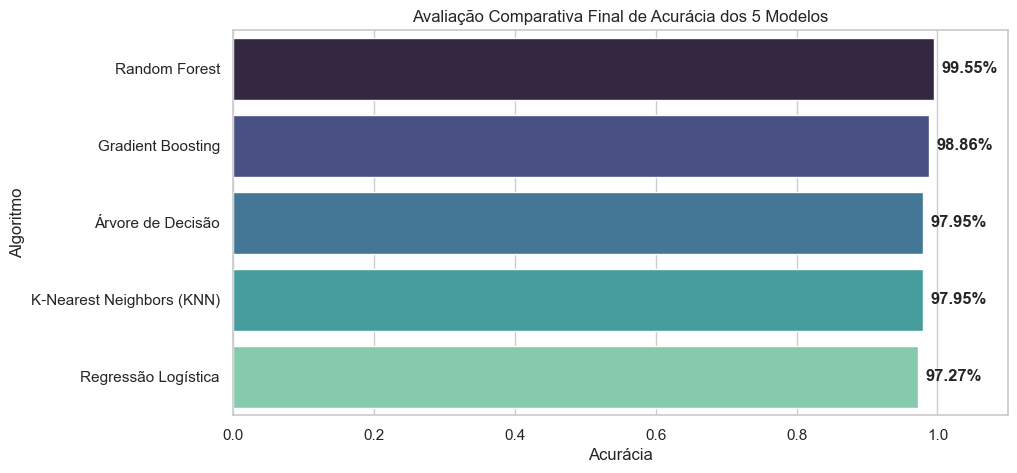

📝 Conclusão de Entrega:
O modelo baseado no algoritmo **Random Forest** obteve o maior desempenho com acurácia de 99.55%. Justifica-se o uso deste algoritmo devido à sua capacidade superior de mapear as correlações de solo e clima do dataset fornecido.


In [24]:
# Gráfico de comparação de desempenho das Acurácias
df_comparativo = pd.DataFrame(list(resultados_acuracia.items()), columns=['Algoritmo', 'Acurácia'])
df_comparativo = df_comparativo.sort_values(by='Acurácia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_comparativo, x='Acurácia', y='Algoritmo', palette='mako')
plt.xlim(0, 1.1)
plt.title('Avaliação Comparativa Final de Acurácia dos 5 Modelos')

for index, value in enumerate(df_comparativo['Acurácia']):
    plt.text(value + 0.01, index, f'{value:.2%}', va='center', fontweight='bold')
plt.show()

# Conclusão automatizada baseada no melhor resultado real
melhor_algoritmo = df_comparativo.iloc[0]['Algoritmo']
melhor_valor = df_comparativo.iloc[0]['Acurácia']

print("📝 Conclusão de Entrega:")
print(f"O modelo baseado no algoritmo **{melhor_algoritmo}** obteve o maior desempenho "
      f"com acurácia de {melhor_valor:.2%}. Justifica-se o uso deste algoritmo "
      f"devido à sua capacidade superior de mapear as correlações de solo e clima do dataset fornecido.")
